# grading in 07-RP

## imports

In [21]:
import duckdb as ddb
from pandas_plots import tbl, pls, hlp
import os

os.environ["RENDERER"]="svg"

hlp.show_package_version()

🐍 3.12.8 | 📦 pandas: 2.3.3 | 📦 numpy: 1.26.4 | 📦 duckdb: 1.4.3 | 📦 pandas-plots: 1.0.0 | 📦 connection-helper: 0.13.2


## settings

In [22]:
DY_MAX = 2023
FILTER_DY = f"z_dy between 2020 and {DY_MAX}"
FILTER_NO_C44 = "z_icd10_3d not in ('C44','D04')"
FILTER_NO_DCO = "not z_is_dco"
FILTER_GRAD = """--sql
    (
        left(z_icd10_3d, 1) ='C' and
        (
            right(z_icd10_3d, 2)::int8 between 00 and 33
            or right(z_icd10_3d, 2)::int8 between 50 and 57
            or right(z_icd10_3d, 2)::int8 between 63 and 68
            or right(z_icd10_3d, 2)::int8 = 60
        )
        and left(Morphologie_Code,4)::int between 8010 and 8576
    )
"""

In [23]:
con = ddb.connect("C://temp/2025-11-11_data_clin.duckdb", read_only=True)

## grading
- **Filter: `DJ` 2020-2023, `DCO` = N, `ICD10`: C00-C33, C50-C57, C60-C68, `Morphologie`: 8010-8576**

In [24]:
filter_list = [
    # ("z_kkr = 7","nur RP"),
    (FILTER_DY, "2020-2023"),
    (FILTER_NO_DCO, "kein DCO"),
    (FILTER_NO_C44, "kein C44,D04"),
    (FILTER_GRAD, "tumorrelevantes Grading"),
]
filters = hlp.get_duckdb_filter_n(
    con=con,
    query="from Tumor",
    filters=filter_list,
)

<!-- START_TOKEN -->

counts: rows
---
n = 3_241_401                              (100.0%) ██████████████████████████████
└ [2020-2023]:               n = 2_989_092  (92.2%) ░░░███████████████████████████
└ [kein DCO]:                n = 2_890_167  (89.2%) ░░░░██████████████████████████
└ [kein C44,D04]:            n = 2_376_104  (73.3%) ░░░░░░░░░█████████████████████
└ [tumorrelevantes Grading]:   n = 997_299  (30.8%) ░░░░░░░░░░░░░░░░░░░░░█████████


<!-- END_TOKEN -->

In [25]:
db_grad=con.sql(f"""--sql
    select
        z_kkr_label,
        Grading,
        case
            when Grading is null then '1_null'
            when Grading in ('T') then '2_trifft_nicht_zu'
            when Grading in ('U') then '3_unknown'
            else '4_valid' end as categ_u,
    from Tumor
    where {filters}
""")
tbl.descr_db(db_grad, "grading")

<!-- START_TOKEN -->

🗄️ grading	997_299, 3
	("z_kkr_label, Grading, categ_u")


<!-- END_TOKEN -->

┌─────────────┬─────────┬─────────┐
│ z_kkr_label │ Grading │ categ_u │
│   varchar   │ varchar │ varchar │
├─────────────┼─────────┼─────────┤
│ 05-NW       │ 3       │ 4_valid │
│ 06-HE       │ 2       │ 4_valid │
│ 07-RP       │ 2       │ 4_valid │
└─────────────┴─────────┴─────────┘



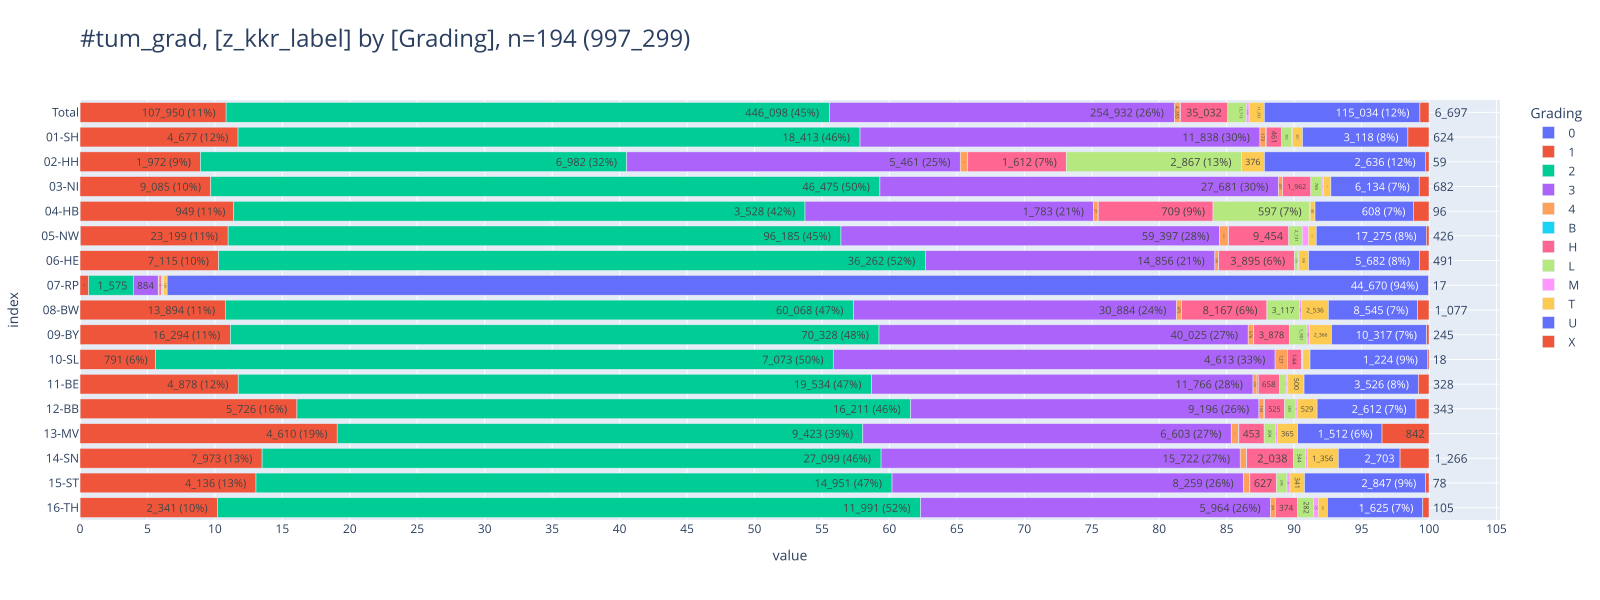

In [26]:
pls.plot_stacked_bars(
    db_grad.to_df().iloc[:,:2],
    relative=True,
    show_total=True,
    orientation="h",
    show_pct_bar=True,
    caption="tum_grad",
    height=600,
    width=1600,
)